### README

In [21]:
# This script summarizes goal behaviors across players in quit condition (N=11)
# Duplicate of 'win' script with different N and 'quit' text

### Import Packages

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Define File Paths

In [23]:
brick_wall_quit = "/Users/baselhussein/Projects/impossible_goals/data/conditions/brick_wall_quit.csv"

### Import Data 

In [24]:
df = pd.read_csv(brick_wall_quit)
df.head()

,ID,Session_timestamp,Level_timestamp,Event_type,Event,Details,epoch_time,Ruleset,win_or_quit,goals,impasses
0,101,0:31:37:783,0:0:8:883,change,update,baba:3:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
1,101,0:31:37:783,0:0:8:883,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
2,101,0:31:38:616,0:0:9:716,change,update,baba:4:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
3,101,0:31:38:616,0:0:9:716,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
4,101,0:31:39:350,0:0:10:450,change,update,baba:5:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN


### Descriptives

#### Count Number of Unique Goals By ID 

In [25]:
unique_goals_by_id = df.groupby('ID')['goals'].nunique()
df_unique_goals_by_id = unique_goals_by_id.to_frame()
df_unique_goals_by_id

,goals
ID,
15,6
49,4
69,1
101,3
157,5
159,6
160,8
178,5
187,5


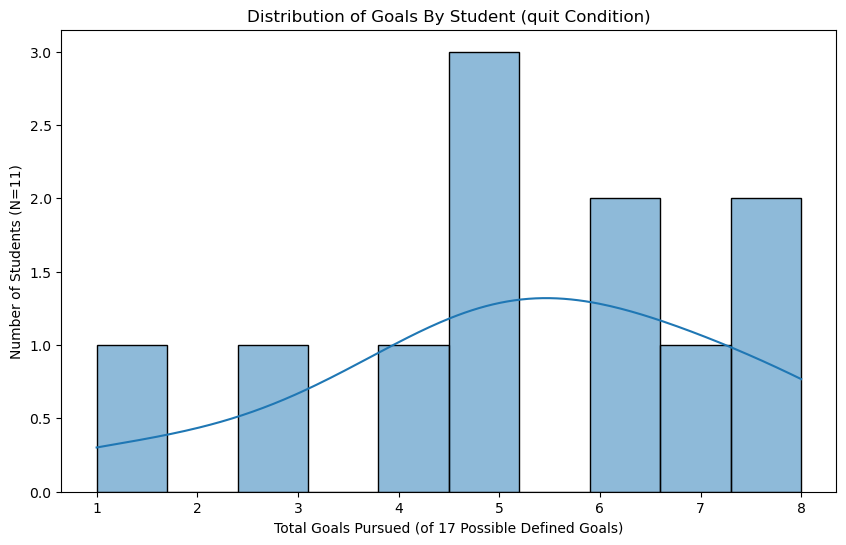

In [26]:
# Visualize the distribution of the 'Total' column
plt.figure(figsize=(10, 6))
sns.histplot(df_unique_goals_by_id['goals'], bins=10, kde=True)
plt.title('Distribution of Goals By Student (quit Condition)')
plt.xlabel('Total Goals Pursued (of 17 Possible Defined Goals)')
plt.ylabel('Number of Students (N=11)')
plt.savefig('/Users/baselhussein/Projects/impossible_goals/output/quit/goals_by_student.png', dpi=300)
plt.show()

#### Number of Returns to Previous Goals

In [27]:
df_returns = df.copy()

In [28]:
for i in range(0, 18):
    df_returns['goals'] = df_returns['goals'].mask(
        df_returns['goals'].eq(f'goal_{i}') & df_returns['goals'].shift().eq(f'goal_{i}')
    )

In [29]:
df_returns

,ID,Session_timestamp,Level_timestamp,Event_type,Event,Details,epoch_time,Ruleset,win_or_quit,goals,impasses
0,101,0:31:37:783,0:0:8:883,change,update,baba:3:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
1,101,0:31:37:783,0:0:8:883,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,NaN,NaN
2,101,0:31:38:616,0:0:9:716,change,update,baba:4:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,NaN,NaN
3,101,0:31:38:616,0:0:9:716,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,NaN,NaN
4,101,0:31:39:350,0:0:10:450,change,update,baba:5:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16603,49,0:54:52:550,0:2:6:350,input,left,NaN,1.643671e+12,"['wall is stop ', 'baba is you ']",NaN,NaN,NaN
16604,49,0:54:52:800,0:2:6:600,change,update,baba:2:6:2,1.643671e+12,"['wall is stop ', 'baba is you ']",NaN,NaN,NaN
16605,49,0:54:52:800,0:2:6:600,input,left,NaN,1.643671e+12,"['wall is stop ', 'baba is you ']",NaN,NaN,NaN
16606,49,0:55:12:433,0:2:26:233,input,end,NaN,1.643671e+12,NaN,quit,NaN,NaN


In [30]:
df_switches_goal = df_returns.groupby('ID')['goals'].value_counts().unstack(fill_value = 'None')
df_switches_goal

goals,goal_0,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9
ID,,,,,,,,,,
15,20,10,8,None,3,1,1,None,None,None
49,6,3,None,2,1,None,None,None,None,None
101,2,1,None,None,None,None,None,None,None,1
157,11,7,None,None,1,1,None,None,2,None
159,34,24,None,None,4,3,None,None,2,1
160,31,11,6,1,4,5,None,2,2,None
178,7,4,None,None,1,1,None,None,None,1
187,19,11,None,None,2,6,3,None,None,None
234,21,8,4,2,4,2,None,None,None,1


In [31]:
df_returns_goal = df_switches_goal.applymap(lambda x: x - 1 if isinstance(x, (int, float)) else x)
df_returns_goal

goals,goal_0,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9
ID,,,,,,,,,,
15,19,9,7,None,2,0,0,None,None,None
49,5,2,None,1,0,None,None,None,None,None
101,1,0,None,None,None,None,None,None,None,0
157,10,6,None,None,0,0,None,None,1,None
159,33,23,None,None,3,2,None,None,1,0
160,30,10,5,0,3,4,None,1,1,None
178,6,3,None,None,0,0,None,None,None,0
187,18,10,None,None,1,5,2,None,None,None
234,20,7,3,1,3,1,None,None,None,0


In [32]:
df_returns_numeric = df_returns_goal.replace('None', 0)
df_returns_numeric['total'] = df_returns_numeric.sum(axis=1)
df_returns_numeric

goals,goal_0,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9,total
ID,,,,,,,,,,,
15,19,9,7,0,2,0,0,0,0,0,37
49,5,2,0,1,0,0,0,0,0,0,8
101,1,0,0,0,0,0,0,0,0,0,1
157,10,6,0,0,0,0,0,0,1,0,17
159,33,23,0,0,3,2,0,0,1,0,62
160,30,10,5,0,3,4,0,1,1,0,54
178,6,3,0,0,0,0,0,0,0,0,9
187,18,10,0,0,1,5,2,0,0,0,36
234,20,7,3,1,3,1,0,0,0,0,35


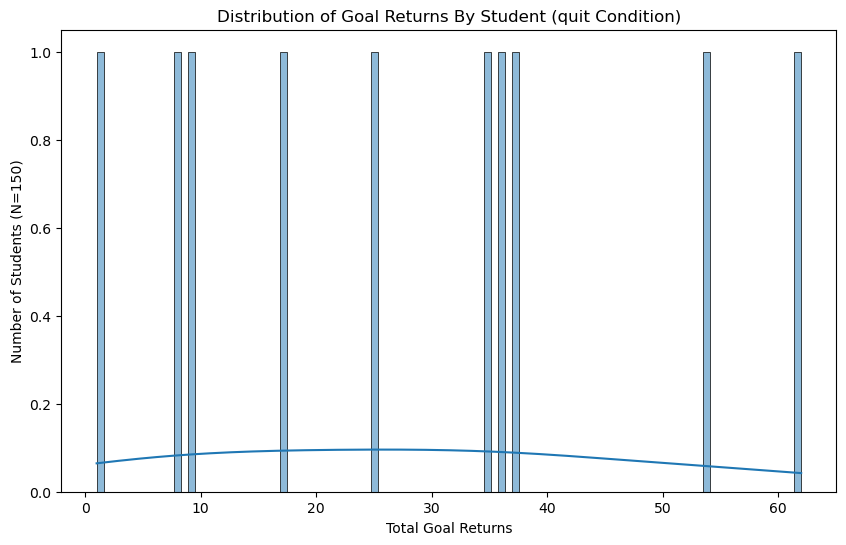

In [33]:
# Visualize the distribution of the 'Total' column
plt.figure(figsize=(10, 6))
sns.histplot(df_returns_numeric['total'], bins=100, kde=True)
plt.title('Distribution of Goal Returns By Student (quit Condition)')
plt.xlabel('Total Goal Returns')
plt.ylabel('Number of Students (N=150)')
plt.savefig('/Users/baselhussein/Projects/impossible_goals/output/quit/goal_returns_by_student.png', dpi=300)
plt.show()

#### Count Number of Goal Switches 

In [34]:
df_switches_numeric = df_switches_goal.replace('None', 0)
df_switches_numeric['total'] = df_switches_numeric.sum(axis=1)
df_switches_numeric

goals,goal_0,goal_1,goal_10,goal_12,goal_2,goal_3,goal_4,goal_5,goal_7,goal_9,total
ID,,,,,,,,,,,
15,20,10,8,0,3,1,1,0,0,0,43
49,6,3,0,2,1,0,0,0,0,0,12
101,2,1,0,0,0,0,0,0,0,1,4
157,11,7,0,0,1,1,0,0,2,0,22
159,34,24,0,0,4,3,0,0,2,1,68
160,31,11,6,1,4,5,0,2,2,0,62
178,7,4,0,0,1,1,0,0,0,1,14
187,19,11,0,0,2,6,3,0,0,0,41
234,21,8,4,2,4,2,0,0,0,1,42


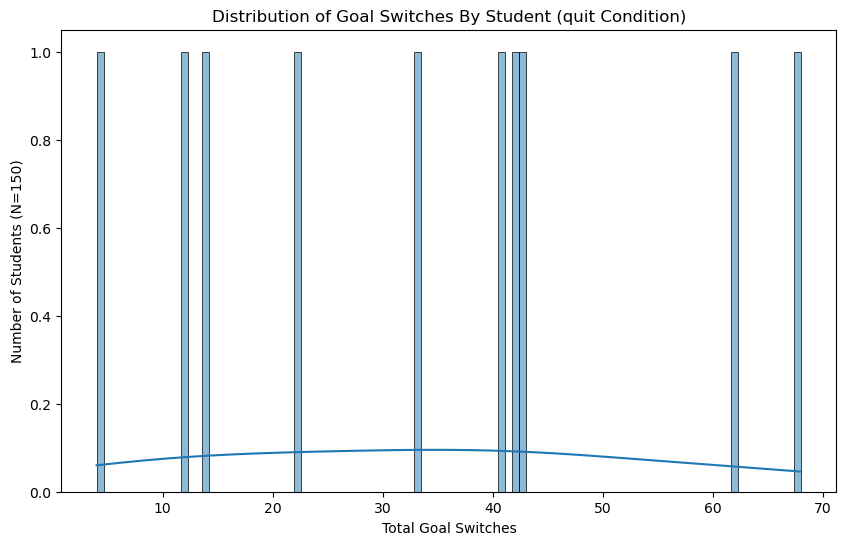

In [35]:
# Visualize the distribution of the 'Total' column
plt.figure(figsize=(10, 6))
sns.histplot(df_switches_numeric['total'], bins=100, kde=True)
plt.title('Distribution of Goal Switches By Student (quit Condition)')
plt.xlabel('Total Goal Switches')
plt.ylabel('Number of Students (N=150)')
plt.savefig('/Users/baselhussein/Projects/impossible_goals/output/quit/goal_switches_by_student.png', dpi=300)
plt.show()

#### Count Total Impasses

In [36]:
impasses_counts_by_player = df.groupby('ID')['impasses'].count()
df_impasses_counts_by_player = impasses_counts_by_player.to_frame()
df_impasses_counts_by_player

,impasses
ID,
15,72
49,19
69,0
101,8
157,23
159,121
160,63
178,24
187,131


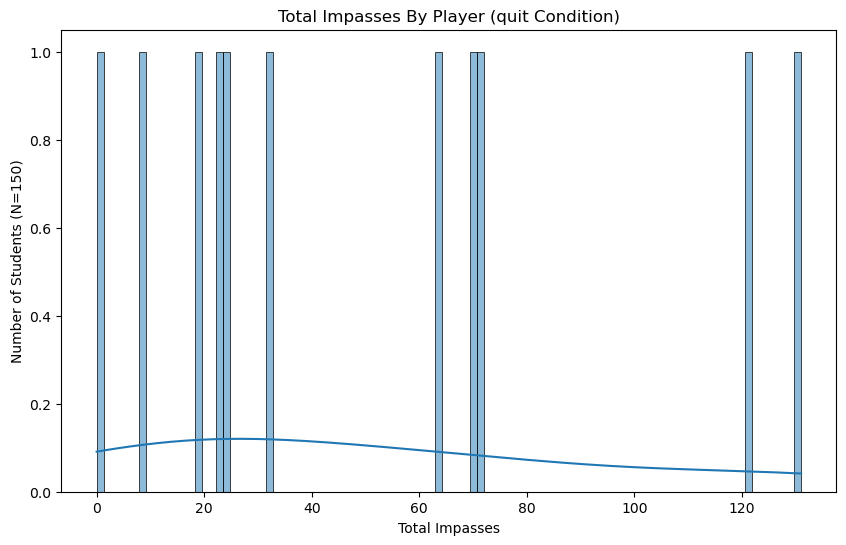

In [37]:
# Visualize the distribution of the 'Total' column
plt.figure(figsize=(10, 6))
sns.histplot(df_impasses_counts_by_player['impasses'], bins=100, kde=True)
plt.title('Total Impasses By Player (quit Condition)')
plt.xlabel('Total Impasses')
plt.ylabel('Number of Students (N=150)')
plt.savefig('/Users/baselhussein/Projects/impossible_goals/output/quit/total_impasses_by_player_in_level.png', dpi=300)
plt.show()

#### Count Impasses By Goal, By Player 

In [38]:
goal_impasse_counts = df.groupby(['ID', 'goals']).agg({'impasses': 'count'}).reset_index()
goal_impasse_counts

,ID,goals,impasses
0,15,goal_0,8
1,15,goal_1,14
2,15,goal_10,14
3,15,goal_2,7
4,15,goal_3,0
5,15,goal_4,29
6,49,goal_0,0
7,49,goal_1,8
8,49,goal_12,6
9,49,goal_2,5


In [39]:
df

,ID,Session_timestamp,Level_timestamp,Event_type,Event,Details,epoch_time,Ruleset,win_or_quit,goals,impasses
0,101,0:31:37:783,0:0:8:883,change,update,baba:3:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
1,101,0:31:37:783,0:0:8:883,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
2,101,0:31:38:616,0:0:9:716,change,update,baba:4:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
3,101,0:31:38:616,0:0:9:716,input,right,NaN,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
4,101,0:31:39:350,0:0:10:450,change,update,baba:5:5:0,1.643393e+12,"['baba is you ', 'flag is win ', 'wall is stop ']",NaN,goal_1,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16603,49,0:54:52:550,0:2:6:350,input,left,NaN,1.643671e+12,"['wall is stop ', 'baba is you ']",NaN,goal_0,NaN
16604,49,0:54:52:800,0:2:6:600,change,update,baba:2:6:2,1.643671e+12,"['wall is stop ', 'baba is you ']",NaN,goal_0,NaN
16605,49,0:54:52:800,0:2:6:600,input,left,NaN,1.643671e+12,"['wall is stop ', 'baba is you ']",NaN,goal_0,NaN
16606,49,0:55:12:433,0:2:26:233,input,end,NaN,1.643671e+12,NaN,quit,goal_0,NaN


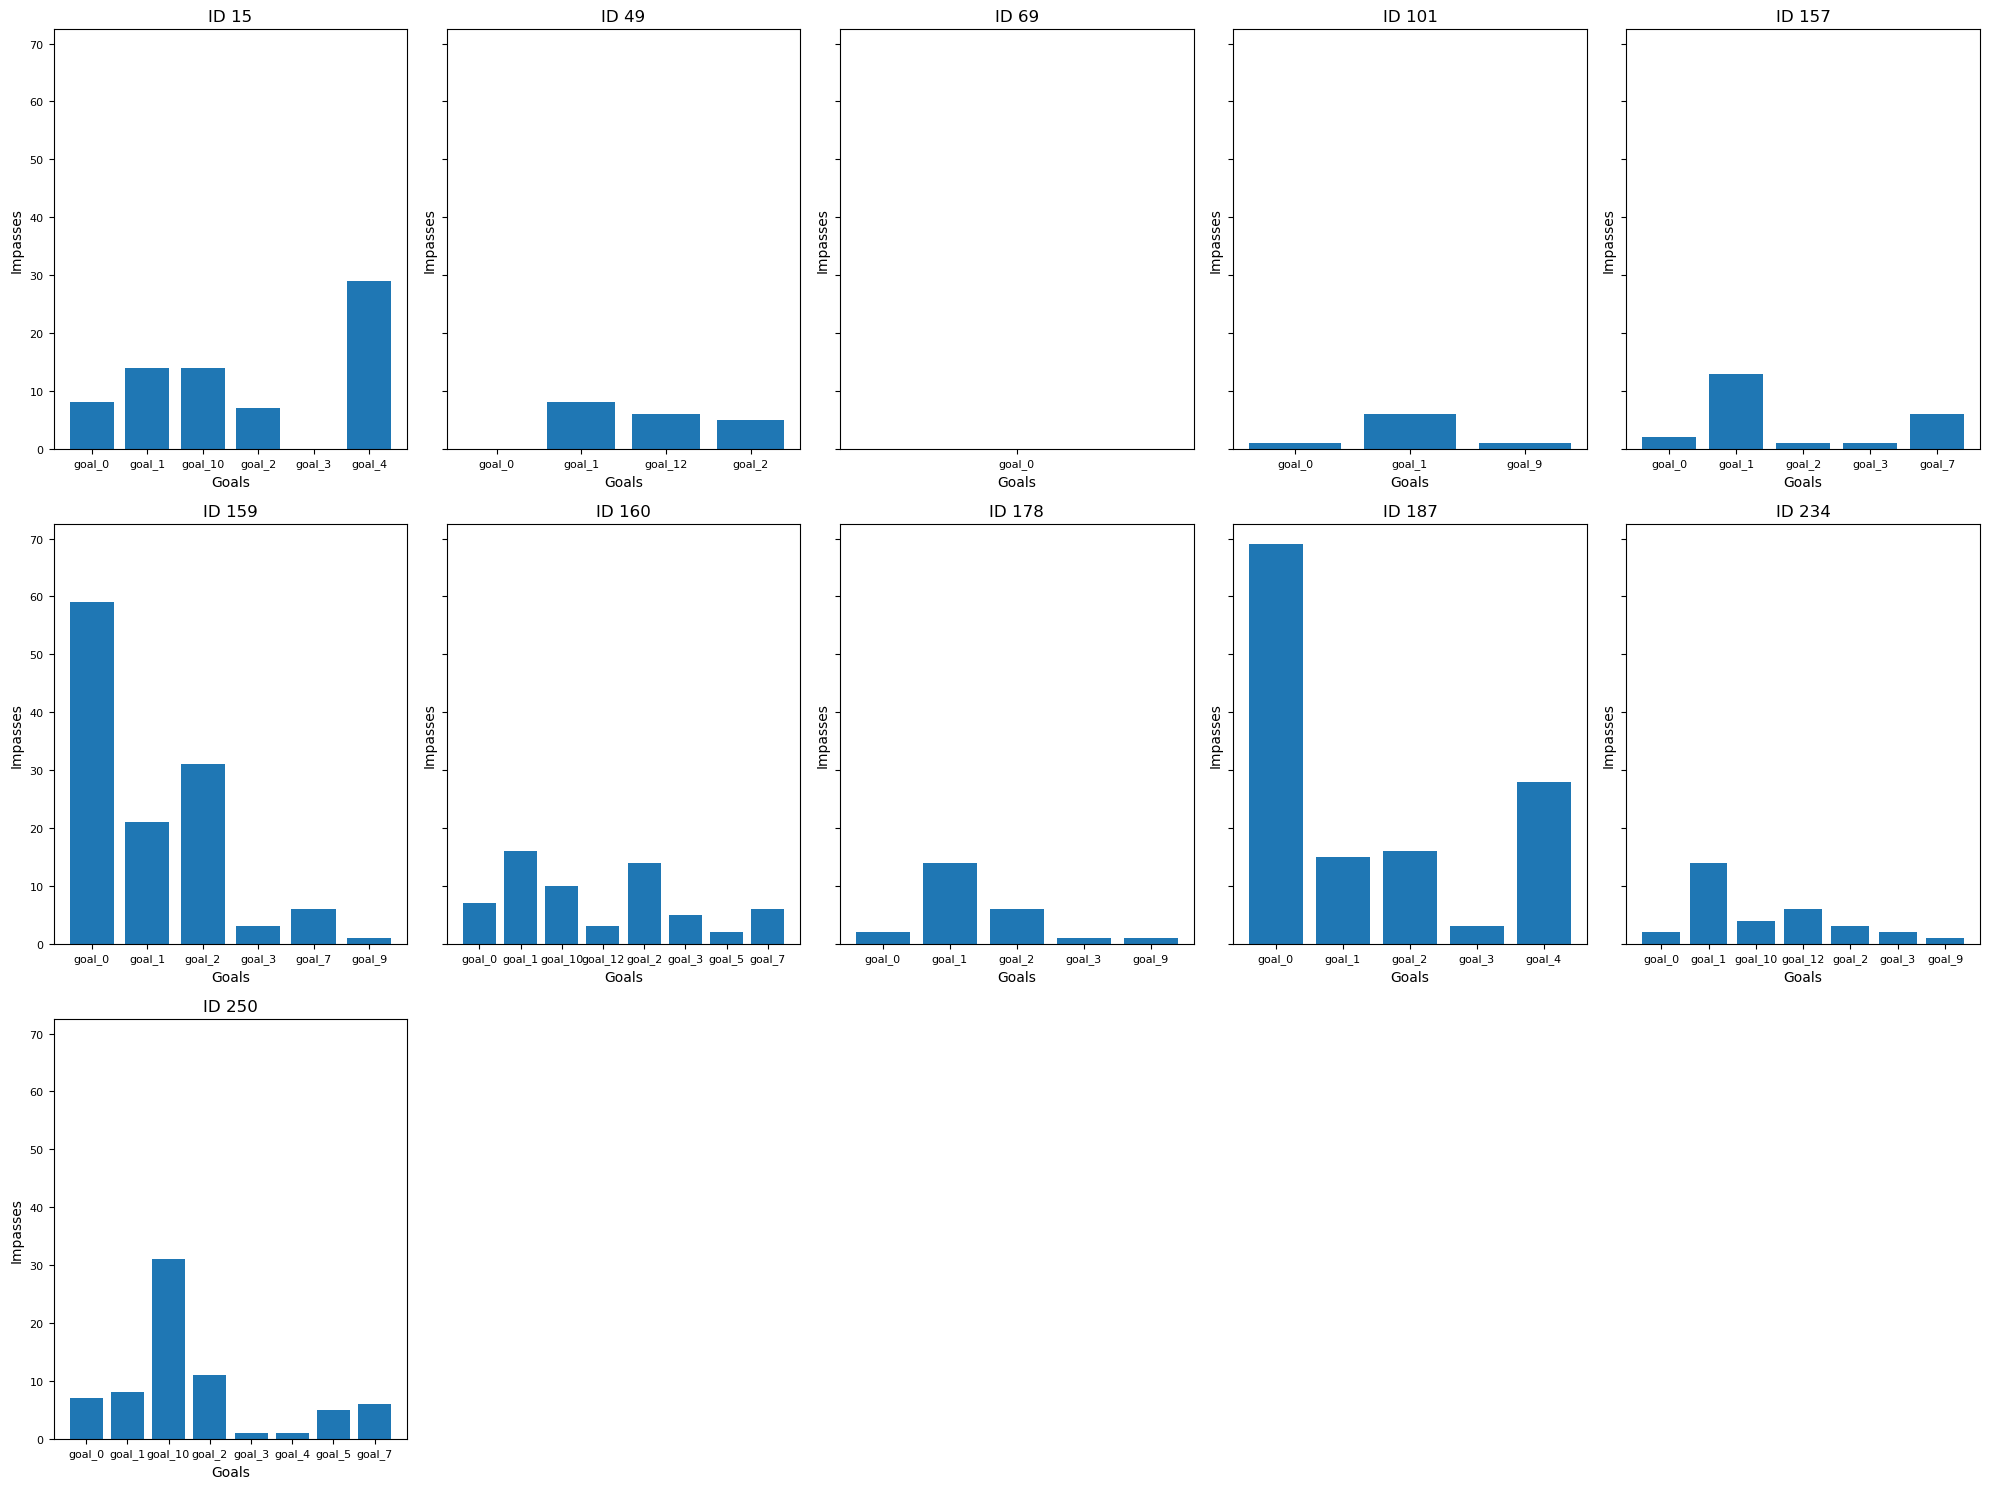

In [40]:
# Get unique IDs
unique_ids = goal_impasse_counts['ID'].unique()

# Set up the plot grid
num_cols = 5  # Number of columns
num_rows = int(np.ceil(len(unique_ids) / num_cols))
fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5*num_rows), sharey=True)

# Flatten the axes array if there's only one row
if num_rows == 1:
    axes = axes.reshape(1, -1)

# Plot each ID's data in a subplot
for i, uid in enumerate(unique_ids):
    ax = axes[i // num_cols, i % num_cols]  # Get the appropriate subplot
    id_data = goal_impasse_counts[goal_impasse_counts['ID'] == uid]  # Data for the current ID
    goals = id_data['goals']
    impasses = id_data['impasses']
    ax.bar(goals, impasses)
    ax.set_title(f'ID {uid}', fontsize=12)  # Set title font size
    ax.set_xlabel('Goals', fontsize=10)  # Set x-axis label font size
    ax.set_ylabel('Impasses', fontsize=10)  # Set y-axis label font size
    ax.tick_params(axis='both', which='major', labelsize=8)  # Set tick label font size

# Hide empty subplots if the number of IDs isn't divisible by the number of columns
if len(unique_ids) % num_cols != 0:
    for j in range(len(unique_ids) % num_cols, num_cols):
        fig.delaxes(axes[num_rows - 1, j])

plt.tight_layout()
plt.savefig('/Users/baselhussein/Projects/impossible_goals/output/quit/impasses_by_goal_by_player.png', dpi=150)
plt.show()
